In [1]:
%matplotlib inline

In [2]:
# =====================
#    IMPORT LIBRARIES
# =====================
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from scipy.sparse import hstack, csr_matrix

# Modeling and evaluation imports
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, make_scorer
)
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.preprocessing import LabelEncoder

                               TASK 1: DATA PREPROCESSING & TF-IDF
###############################################################################

In [3]:
# --- Data Loading ---
disease_df = pd.read_csv("disease_features.csv")
one_hot_df = pd.read_csv("encoded_output2.csv")

print("Disease DataFrame HEAD:")
print(disease_df.head(), "\n")
print("One-hot Encoded DataFrame HEAD:")
print(one_hot_df.head(), "\n")

# --- Parse and Convert Text Columns ---
def parse_string_list(str_list):
    """Convert a stringified list into a Python list."""
    try:
        return ast.literal_eval(str_list)
    except:
        return []

text_columns = ["Risk Factors", "Symptoms", "Signs"]
for col in text_columns:
    disease_df[col] = disease_df[col].apply(parse_string_list)
    # Convert the list to a space-separated string
    disease_df[col] = disease_df[col].apply(lambda x: " ".join(x))

# --- TF-IDF Vectorization ---
tfidf_vectors = []
vectorizers = {}
for col in text_columns:
    vectorizer = TfidfVectorizer()
    mat = vectorizer.fit_transform(disease_df[col])
    tfidf_vectors.append(mat)
    vectorizers[col] = vectorizer

# Combine the three TF-IDF matrices horizontally
tfidf_feature_matrix = hstack(tfidf_vectors)
print("Combined TF-IDF matrix shape:", tfidf_feature_matrix.shape)

# --- One-hot Encoded Matrix ---
# Assume the first column of one_hot_df is the label; use remaining as features.
one_hot_data = one_hot_df.iloc[:, 1:].values
onehot_matrix = csr_matrix(one_hot_data)

# Compare Sparsity and Feature Count
tfidf_nnz = tfidf_feature_matrix.nnz
onehot_nnz = onehot_matrix.nnz
total_tfidf = tfidf_feature_matrix.shape[0] * tfidf_feature_matrix.shape[1]
total_onehot = onehot_matrix.shape[0] * onehot_matrix.shape[1]

tfidf_sparsity = 1 - (tfidf_nnz / total_tfidf)
onehot_sparsity = 1 - (onehot_nnz / total_onehot)

print(f"TF-IDF sparsity: {tfidf_sparsity:.4f}")
print(f"One-hot sparsity: {onehot_sparsity:.4f}")

total_tfidf_features = sum(len(vectorizers[c].vocabulary_) for c in text_columns)
onehot_features = onehot_matrix.shape[1]
print(f"Total unique TF-IDF features (combined): {total_tfidf_features}")
print(f"Total one-hot features: {onehot_features}")

Disease DataFrame HEAD:
                   Disease                                       Risk Factors  \
0  Acute Coronary Syndrome  ['Hyperlipidemia', 'hypertension', 'smoking', ...   
1    Adrenal Insufficiency  ['Autoimmune diseases', 'Genetic predispositio...   
2                Alzheimer  ['Age', 'genetic factors', 'gender', 'cardiova...   
3        Aortic Dissection  ['Hypertension', 'Atherosclerosis', 'Family hi...   
4                   Asthma  ['Allergies', 'family history of asthma or all...   

                                            Symptoms  \
0  ['Chest pain', 'sweating', 'nausea', 'vomiting...   
1  ['Fatigue', 'Muscle weakness', 'Weight loss', ...   
2  ['Cognitive decline, including memory loss and...   
3  ['Intense chest or upper back pain', 'Sudden s...   
4  ['Recurrent episodes of wheezing', 'breathless...   

                                               Signs  \
0                                                 []   
1  ['Hyperpigmentation (especially in cr

                               TASK 2: DIMENSIONALITY REDUCTION & VISUALIZATION
###############################################################################

Initial target used: 'Disease'. Unique classes: ['Acute Coronary Syndrome' 'Adrenal Insufficiency' 'Alzheimer'
 'Aortic Dissection' 'Asthma' 'Atrial Fibrillation' 'Cardiomyopathy'
 'COPD' 'Diabetes' 'Epilepsy' 'Gastritis'
 'Gastro-oesophageal Reflux Disease' 'Heart Failure' 'Hyperlipidemia'
 'Hypertension' 'Migraine' 'Multiple Sclerosis' 'Peptic Ulcer Disease'
 'Pituitary Disease' 'Pneumonia' 'Pulmonary Embolism' 'Stroke'
 'Thyroid Disease' 'Tuberculosis' 'Upper Gastrointestinal Bleeding']
Final target used for modeling: 'synthetic_target'
Encoded target classes: [0 1]

Explained variance ratio (TF-IDF PCA): [0.06583913 0.05897588]
Explained variance ratio (One-hot PCA): [0.10538866 0.09170854]

Explained variance ratio (TF-IDF SVD): [0.00886477 0.06571728]
Explained variance ratio (One-hot SVD): [0.02247731 0.09194331]


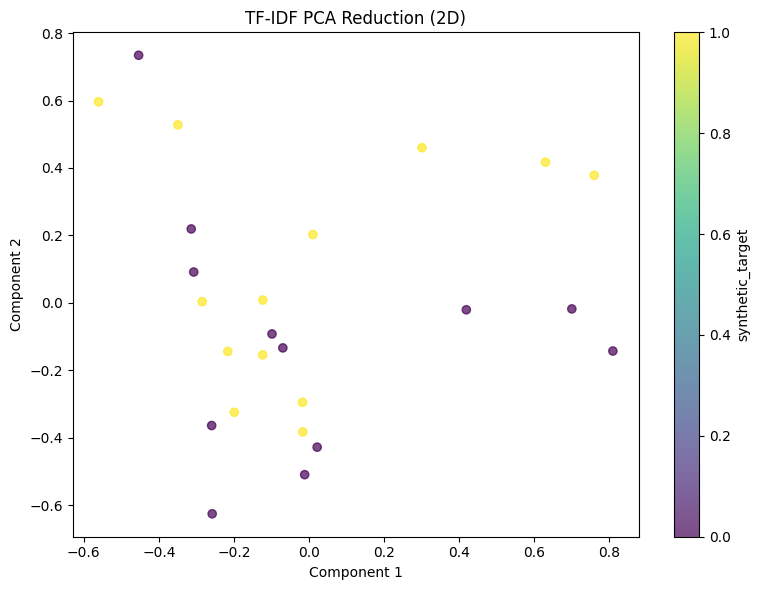

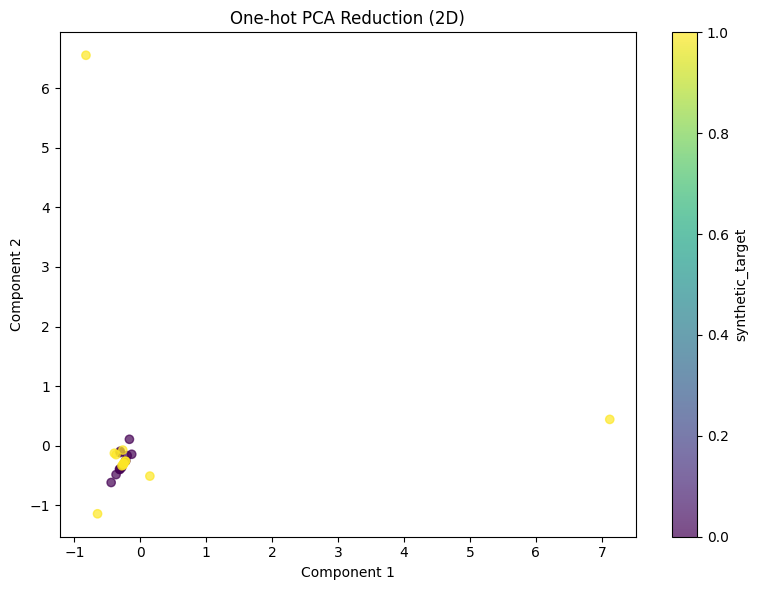

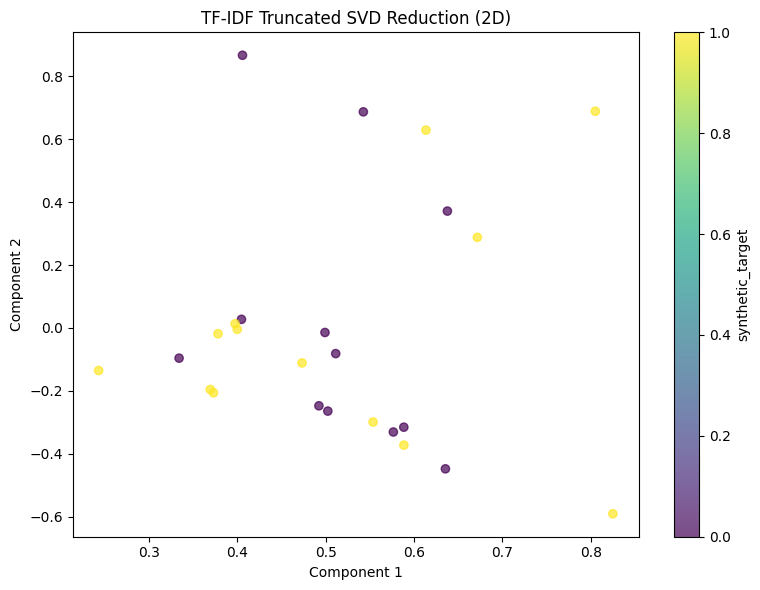

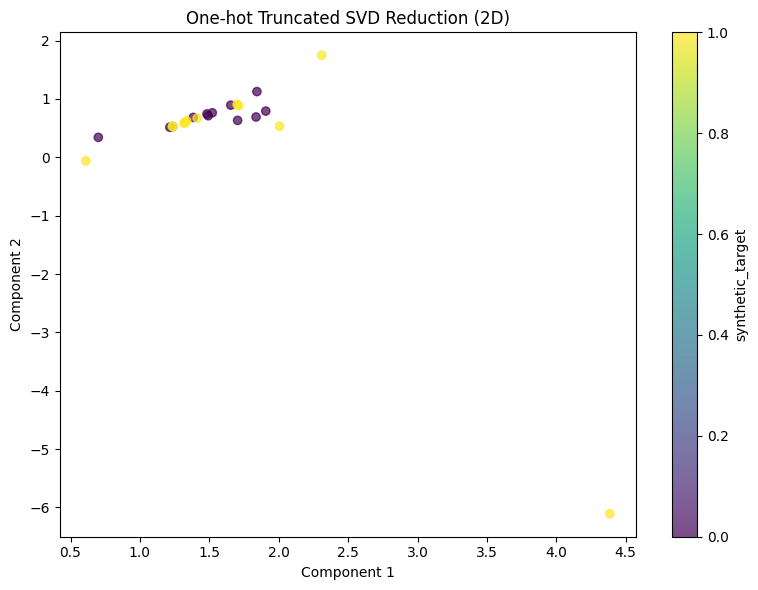

In [4]:
# --- Target Variable Selection ---
# Prefer "Disease" column if available, else "Subtype"
if "Disease" in disease_df.columns:
    target_col = "Disease"
elif "Subtype" in disease_df.columns:
    target_col = "Subtype"
else:
    raise ValueError("No target column ('Disease' or 'Subtype') found.")

# Create a new target column in the dataframe
disease_df['target'] = disease_df[target_col]
print(f"Initial target used: '{target_col}'. Unique classes: {disease_df['target'].unique()}")

# --- Check Target Distribution; Create Synthetic Target if Needed ---
# If each sample has a unique target, we create a synthetic binary target.
if disease_df['target'].nunique() == len(disease_df):
    print("WARNING: Each sample has a unique target. Creating a synthetic target for evaluation.")
    half = len(disease_df) // 2
    disease_df['synthetic_target'] = ['Class_A' if i < half else 'Class_B' for i in range(len(disease_df))]
    target_used = 'synthetic_target'
else:
    target_used = target_col

# Set final target for modeling
df_target = disease_df[target_used]
label_enc = LabelEncoder()
encoded_target = label_enc.fit_transform(df_target)
print(f"Final target used for modeling: '{target_used}'")
print("Encoded target classes:", np.unique(encoded_target))

# --- Prepare Feature Matrices for Dimensionality Reduction ---
# Convert TF-IDF matrix to dense for PCA.
tfidf_array = tfidf_feature_matrix.toarray()
onehot_array = onehot_matrix.toarray()

# --- PCA ---
pca_tfidf = PCA(n_components=2, random_state=42)
tfidf_pca_2d = pca_tfidf.fit_transform(tfidf_array)

pca_onehot = PCA(n_components=2, random_state=42)
onehot_pca_2d = pca_onehot.fit_transform(onehot_array)

print("\nExplained variance ratio (TF-IDF PCA):", pca_tfidf.explained_variance_ratio_)
print("Explained variance ratio (One-hot PCA):", pca_onehot.explained_variance_ratio_)

# --- Truncated SVD ---
svd_tfidf = TruncatedSVD(n_components=2, random_state=42)
tfidf_svd_2d = svd_tfidf.fit_transform(tfidf_feature_matrix)

svd_onehot = TruncatedSVD(n_components=2, random_state=42)
onehot_svd_2d = svd_onehot.fit_transform(onehot_matrix)

print("\nExplained variance ratio (TF-IDF SVD):", svd_tfidf.explained_variance_ratio_)
print("Explained variance ratio (One-hot SVD):", svd_onehot.explained_variance_ratio_)

# --- 2D Plot Function ---
def plot_2d(data, title):
    plt.figure(figsize=(8,6))
    sc = plt.scatter(data[:, 0], data[:, 1], c=encoded_target, cmap='viridis', alpha=0.7)
    plt.title(title)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.colorbar(sc, label=target_used)
    plt.tight_layout()
    plt.show()

plot_2d(tfidf_pca_2d, "TF-IDF PCA Reduction (2D)")
plot_2d(onehot_pca_2d, "One-hot PCA Reduction (2D)")
plot_2d(tfidf_svd_2d, "TF-IDF Truncated SVD Reduction (2D)")
plot_2d(onehot_svd_2d, "One-hot Truncated SVD Reduction (2D)")

                               TASK 3: CLASSIFICATION & EVALUATION
###############################################################################

In [5]:
# Define functions for model evaluation using cross-validation.
def cross_validate_knn(X, y, k_values=[3,5,7], metrics=["euclidean", "manhattan", "cosine"], folds=5):
    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)
    results = []
    for k in k_values:
        for dist in metrics:
            accs, precs, recs, f1s = [], [], [], []
            for train_ix, test_ix in skf.split(X, y):
                X_tr, X_te = X[train_ix], X[test_ix]
                y_tr, y_te = y[train_ix], y[test_ix]
                clf = KNeighborsClassifier(n_neighbors=k, metric=dist)
                clf.fit(X_tr, y_tr)
                y_pred = clf.predict(X_te)
                accs.append(accuracy_score(y_te, y_pred))
                precs.append(precision_score(y_te, y_pred, average='weighted', zero_division=0))
                recs.append(recall_score(y_te, y_pred, average='weighted', zero_division=0))
                f1s.append(f1_score(y_te, y_pred, average='weighted', zero_division=0))
            results.append({
                "K": k,
                "Metric": dist,
                "Accuracy": np.mean(accs),
                "Precision": np.mean(precs),
                "Recall": np.mean(recs),
                "F1-score": np.mean(f1s)
            })
    return pd.DataFrame(results)

def cross_validate_logreg(X, y, folds=5):
    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)
    accs, f1s = [], []
    for train_ix, test_ix in skf.split(X, y):
        X_tr, X_te = X[train_ix], X[test_ix]
        y_tr, y_te = y[train_ix], y[test_ix]
        clf = LogisticRegression(max_iter=1000, multi_class='auto', random_state=42)
        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_te)
        accs.append(accuracy_score(y_te, y_pred))
        f1s.append(f1_score(y_te, y_pred, average='weighted', zero_division=0))
    return np.mean(accs), np.mean(f1s)

# Check the distribution in the (encoded) target variable.
unique_vals, counts = np.unique(encoded_target, return_counts=True)
min_count = counts.min()
print("\nClass distribution in target (encoded):", dict(zip(unique_vals, counts)))

# If every class has ≥5 samples, proceed with 5-fold cross-validation.
if min_count >= 5:
    print("\nProceeding with 5-Fold Cross-Validation.\n")
    print("KNN on TF-IDF (5-fold CV):")
    knn_tfidf_results = cross_validate_knn(tfidf_feature_matrix, encoded_target, folds=5)
    print(knn_tfidf_results)
    
    print("\nKNN on One-hot (5-fold CV):")
    knn_onehot_results = cross_validate_knn(onehot_matrix, encoded_target, folds=5)
    print(knn_onehot_results)
    
    print("\nLogistic Regression on TF-IDF (5-fold CV):")
    lr_tfidf_acc, lr_tfidf_f1 = cross_validate_logreg(tfidf_feature_matrix, encoded_target, folds=5)
    print(f"Accuracy: {lr_tfidf_acc:.3f}, F1: {lr_tfidf_f1:.3f}")
    
    print("\nLogistic Regression on One-hot (5-fold CV):")
    lr_onehot_acc, lr_onehot_f1 = cross_validate_logreg(onehot_matrix, encoded_target, folds=5)
    print(f"Accuracy: {lr_onehot_acc:.3f}, F1: {lr_onehot_f1:.3f}")
else:
    # Fall back to a non-stratified single train/test split if some class has <5 samples.
    print("\nWARNING: Some class has fewer than 5 samples. 5-fold CV is not possible.")
    print("Falling back to a non-stratified single train/test split (results may be unreliable).")
    
    X_tfidf = tfidf_array
    X_onehot = onehot_array
    y_model = encoded_target
    
    X_train_tf, X_test_tf, y_train, y_test = train_test_split(X_tfidf, y_model, test_size=0.3, random_state=42)
    print("Train distribution:", dict(zip(*np.unique(y_train, return_counts=True))))
    print("Test distribution:", dict(zip(*np.unique(y_test, return_counts=True))))
    
    knn = KNeighborsClassifier(n_neighbors=3, metric="euclidean")
    knn.fit(X_train_tf, y_train)
    y_pred_tf = knn.predict(X_test_tf)
    print("\nSingle Train/Test KNN on TF-IDF (k=3, Euclidean):")
    print("Accuracy:", accuracy_score(y_test, y_pred_tf))
    print("Precision:", precision_score(y_test, y_pred_tf, average='weighted', zero_division=0))
    print("Recall:", recall_score(y_test, y_pred_tf, average='weighted', zero_division=0))
    print("F1:", f1_score(y_test, y_pred_tf, average='weighted', zero_division=0))
    
    X_train_oh, X_test_oh, y_train_oh, y_test_oh = train_test_split(X_onehot, y_model, test_size=0.3, random_state=42)
    knn_oh = KNeighborsClassifier(n_neighbors=3, metric="euclidean")
    knn_oh.fit(X_train_oh, y_train_oh)
    y_pred_oh = knn_oh.predict(X_test_oh)
    print("\nSingle Train/Test KNN on One-hot (k=3, Euclidean):")
    print("Accuracy:", accuracy_score(y_test_oh, y_pred_oh))
    print("Precision:", precision_score(y_test_oh, y_pred_oh, average='weighted', zero_division=0))
    print("Recall:", recall_score(y_test_oh, y_pred_oh, average='weighted', zero_division=0))
    print("F1:", f1_score(y_test_oh, y_pred_oh, average='weighted', zero_division=0))
    
    lr = LogisticRegression(max_iter=1000, multi_class='auto', random_state=42)
    lr.fit(X_train_tf, y_train)
    y_pred_lr = lr.predict(X_test_tf)
    print("\nSingle Train/Test Logistic Regression on TF-IDF:")
    print("Accuracy:", accuracy_score(y_test, y_pred_lr))
    print("F1:", f1_score(y_test, y_pred_lr, average='weighted', zero_division=0))
    
    lr_oh = LogisticRegression(max_iter=1000, multi_class='auto', random_state=42)
    lr_oh.fit(X_train_oh, y_train_oh)
    y_pred_lr_oh = lr_oh.predict(X_test_oh)
    print("\nSingle Train/Test Logistic Regression on One-hot:")
    print("Accuracy:", accuracy_score(y_test_oh, y_pred_lr_oh))
    print("F1:", f1_score(y_test_oh, y_pred_lr_oh, average='weighted', zero_division=0))


Class distribution in target (encoded): {np.int64(0): np.int64(12), np.int64(1): np.int64(13)}

Proceeding with 5-Fold Cross-Validation.

KNN on TF-IDF (5-fold CV):


C:\Users\abbas\AppData\Roaming\Python\Python313\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\abbas\AppData\Roaming\Python\Python313\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Python313\Lib\subprocess.py", line 1036, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^

   K     Metric  Accuracy  Precision  Recall  F1-score
0  3  euclidean      0.44   0.302667    0.44  0.337143
1  3  manhattan      0.48   0.328000    0.48  0.340476
2  3     cosine      0.40   0.365333    0.40  0.365714
3  5  euclidean      0.48   0.404000    0.48  0.393333
4  5  manhattan      0.44   0.276000    0.44  0.328095
5  5     cosine      0.52   0.478667    0.52  0.485714
6  7  euclidean      0.40   0.242667    0.40  0.288095
7  7  manhattan      0.48   0.240000    0.48  0.317143
8  7     cosine      0.40   0.365333    0.40  0.365714

KNN on One-hot (5-fold CV):
   K     Metric  Accuracy  Precision  Recall  F1-score
0  3  euclidean      0.56   0.378000    0.56  0.427619
1  3  manhattan      0.56   0.378000    0.56  0.427619
2  3     cosine      0.48   0.380667    0.48  0.398571
3  5  euclidean      0.56   0.378000    0.56  0.427619
4  5  manhattan      0.56   0.378000    0.56  0.427619
5  5     cosine      0.48   0.380667    0.48  0.398571
6  7  euclidean      0.48   0.322667

C:\Users\abbas\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\abbas\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\abbas\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\abbas\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_mo